In [1]:
# CELL 1: Import required libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("✅ Libraries imported successfully")


✅ Libraries imported successfully


In [2]:
# CELL 2: Load dataset

data_path = "../backend/data/asteroid_data.csv"   # keep your path same
df = pd.read_csv(data_path)

print("✅ Dataset loaded successfully")
print("Shape:", df.shape)
df.head()


✅ Dataset loaded successfully
Shape: (90836, 10)


,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.24922,54839744.08,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.72666,61438126.52,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.69210,49798724.94,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.30314,25434972.72,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.73376,46275567.00,Earth,False,20.09,True


In [3]:
# CELL 3: Select features and target

features = [
    "est_diameter_min",
    "est_diameter_max",
    "relative_velocity",
    "miss_distance",
    "absolute_magnitude"
]

X = df[features].copy()
y = df["hazardous"].copy()

print("✅ Features:", features)
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())
print("\nClass percentage:")
print(y.value_counts(normalize=True) * 100)


✅ Features: ['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude']
X shape: (90836, 5)
y shape: (90836,)

Class distribution:
hazardous
False    81996
True      8840
Name: count, dtype: int64

Class percentage:
hazardous
False    90.268176
True      9.731824
Name: proportion, dtype: float64


In [4]:
# CELL 4: Handle missing values

print("Missing values per column:")
print(X.isnull().sum())

X = X.fillna(X.mean(numeric_only=True))

print("\n✅ Missing values handled")


Missing values per column:
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
absolute_magnitude    0
dtype: int64

✅ Missing values handled


In [6]:
# CELL 5: Train-test split + scaling

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# scaling only for LR/SVM
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Split done")
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
test_percent = 0.2 * 100
train_percent = (1 - 0.2) * 100

print(f"Train-Test Split Ratio = {int(train_percent)}-{int(test_percent)}")


✅ Split done
Train shape: (72668, 5) (72668,)
Test shape: (18168, 5) (18168,)
Train-Test Split Ratio = 80-20


In [7]:
# CELL 6: Evaluation function (same for all models)

def evaluate_model(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred) * 100
    prec = precision_score(y_true, y_pred) * 100
    rec = recall_score(y_true, y_pred) * 100
    f1 = f1_score(y_true, y_pred) * 100

    return {
        "Model": model_name,
        "Accuracy (%)": round(acc, 2),
        "Precision (%)": round(prec, 2),
        "Recall (%)": round(rec, 2),
        "F1 Score (%)": round(f1, 2)
    }


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler

# 1) Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2) Train LR (balanced)
lr = LogisticRegression(max_iter=3000, class_weight="balanced")
lr.fit(X_train_scaled, y_train)

# 3) Get probabilities
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

# 4) Try higher threshold for better accuracy
threshold = 0.70   # try: 0.60, 0.65, 0.70, 0.75, 0.80
y_pred = (y_prob >= threshold).astype(int)

print("Logistic Regression (Threshold =", threshold, ")")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred, zero_division=0))
print("\n", classification_report(y_test, y_pred))


Logistic Regression (Threshold = 0.7 )
Accuracy : 0.8261778952003522
Precision: 0.316622691292876
Recall   : 0.6787330316742082
F1 Score : 0.4318100035984167

               precision    recall  f1-score   support

       False       0.96      0.84      0.90     16400
        True       0.32      0.68      0.43      1768

    accuracy                           0.83     18168
   macro avg       0.64      0.76      0.66     18168
weighted avg       0.90      0.83      0.85     18168



In [11]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---- Metrics ----
acc = accuracy_score(y_test, y_pred) * 100
prec = precision_score(y_test, y_pred, zero_division=0) * 100
rec = recall_score(y_test, y_pred, zero_division=0) * 100
f1 = f1_score(y_test, y_pred, zero_division=0) * 100

# ---- Table like report ----
lr_table = pd.DataFrame([{
    "Split": "80-20",
    "Accuracy (%)": round(acc, 2),
    "Precision (%)": round(prec, 2),
    "Recall (%)": round(rec, 2),
    "F1-Score (%)": round(f1, 2)
}])

lr_table


,Split,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,80-20,82.62,31.66,67.87,43.18


In [12]:
# CELL 8: SVM (with class_weight balanced)

from sklearn.svm import SVC

svm = SVC(class_weight="balanced", probability=True)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

print("✅ SVM trained")
print(classification_report(y_test, y_pred_svm))


✅ SVM trained
              precision    recall  f1-score   support

       False       1.00      0.74      0.85     16400
        True       0.29      0.99      0.46      1768

    accuracy                           0.77     18168
   macro avg       0.65      0.87      0.65     18168
weighted avg       0.93      0.77      0.81     18168



In [13]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---- Metrics ----
acc = accuracy_score(y_test, y_pred_svm) * 100
prec = precision_score(y_test, y_pred_svm, zero_division=0) * 100
rec = recall_score(y_test, y_pred_svm, zero_division=0) * 100
f1 = f1_score(y_test, y_pred_svm, zero_division=0) * 100

# ---- Table ----
svm_table = pd.DataFrame([{
    "Split": "80-20",
    "Accuracy (%)": round(acc, 2),
    "Precision (%)": round(prec, 2),
    "Recall (%)": round(rec, 2),
    "F1-Score (%)": round(f1, 2)
}])

svm_table


,Split,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,80-20,76.81,29.5,99.49,45.51


In [17]:

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_bal).value_counts())


Before SMOTE: hazardous
False    65596
True      7072
Name: count, dtype: int64
After SMOTE: hazardous
False    65596
True     65596
Name: count, dtype: int64


In [19]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_bal, y_train_bal)

y_pred_dt = dt.predict(X_test_scaled)

print("Decision Tree Results")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_dt, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_dt, zero_division=0))
print("\n", classification_report(y_test, y_pred_dt))


Decision Tree Results
Accuracy : 0.8883201232937032
Precision: 0.44338394793926245
Recall   : 0.5780542986425339
F1 Score : 0.5018413945494722

               precision    recall  f1-score   support

       False       0.95      0.92      0.94     16400
        True       0.44      0.58      0.50      1768

    accuracy                           0.89     18168
   macro avg       0.70      0.75      0.72     18168
weighted avg       0.90      0.89      0.89     18168



In [20]:
# CELL 10: Random Forest (with class_weight balanced)

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("✅ Random Forest trained")
print(classification_report(y_test, y_pred_rf))


✅ Random Forest trained
              precision    recall  f1-score   support

       False       0.94      0.97      0.96     16400
        True       0.62      0.40      0.49      1768

    accuracy                           0.92     18168
   macro avg       0.78      0.69      0.72     18168
weighted avg       0.91      0.92      0.91     18168



In [22]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train_bal, y_train_bal)

y_pred_xgb = xgb.predict(X_test_scaled)

print("XGBoost Results")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_xgb, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("\n", classification_report(y_test, y_pred_xgb))


XGBoost Results
Accuracy : 0.8181968295904888
Precision: 0.3394015484410965
Recall   : 0.917420814479638
F1 Score : 0.49549411944402016

               precision    recall  f1-score   support

       False       0.99      0.81      0.89     16400
        True       0.34      0.92      0.50      1768

    accuracy                           0.82     18168
   macro avg       0.66      0.86      0.69     18168
weighted avg       0.93      0.82      0.85     18168



In [25]:
import pandas as pd

results = []

# LR table
results.append(evaluate_model("Logistic Regression", y_test, y_pred))

# SVM table
results.append(evaluate_model("SVM", y_test, y_pred_svm))

# Decision Tree table
results.append(evaluate_model("Decision Tree", y_test, y_pred_dt))

# Random Forest table
results.append(evaluate_model("Random Forest", y_test, y_pred_rf))

# XGBoost table
results.append(evaluate_model("XGBoost", y_test, y_pred_xgb))

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.826178,0.316623,0.678733,0.431810
1,SVM,0.768109,0.294986,0.994910,0.455051
2,Decision Tree,0.888320,0.443384,0.578054,0.501841
3,Random Forest,0.918043,0.624000,0.397059,0.485309
4,XGBoost,0.818197,0.339402,0.917421,0.495494


In [27]:
import os
import joblib
import json

MODEL_DIR = r"E:\Asteroid Hazard Prediction Project\backend\model"
os.makedirs(MODEL_DIR, exist_ok=True)

# Save Random Forest model
joblib.dump(rf, os.path.join(MODEL_DIR, "random_forest.pkl"))

# Save threshold only if you did threshold tuning
try:
    with open(os.path.join(MODEL_DIR, "best_threshold.json"), "w") as f:
        json.dump({"best_threshold": float(best_threshold)}, f)
except:
    print("⚠️ best_threshold not found, skipping threshold save")

# Save features list
with open(os.path.join(MODEL_DIR, "features.json"), "w") as f:
    json.dump(features, f)

print("✅ Model saved successfully in E:\\AHP\\backend\\model")


⚠️ best_threshold not found, skipping threshold save
✅ Model saved successfully in E:\AHP\backend\model


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


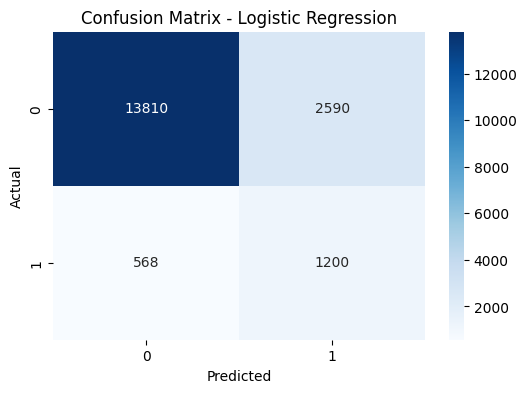

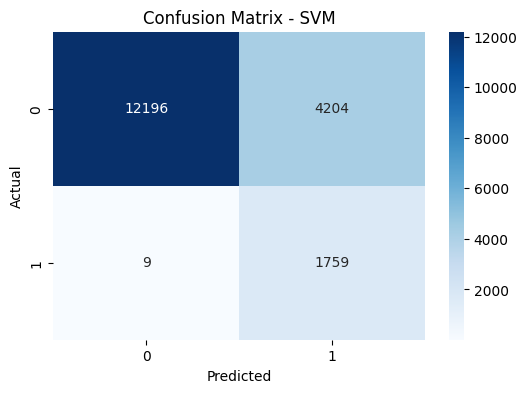

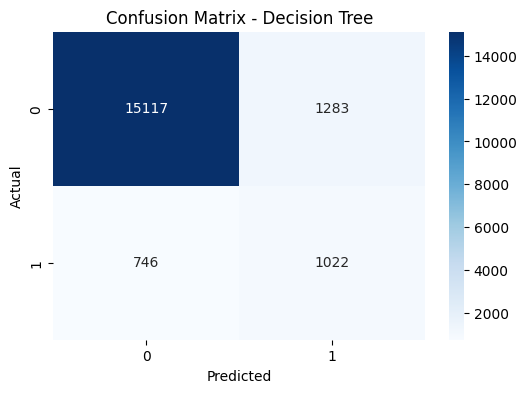

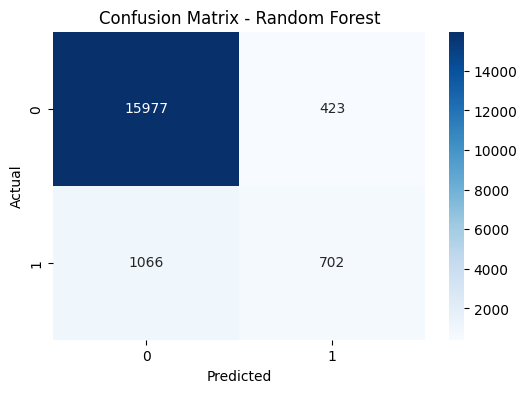

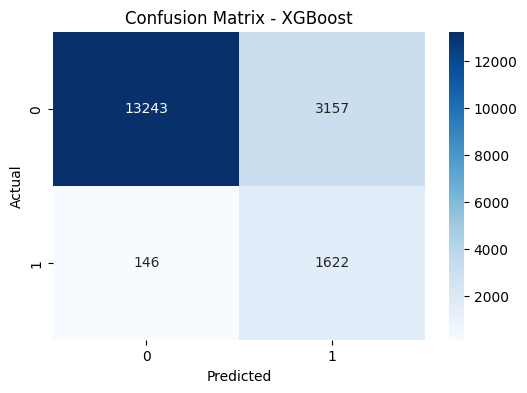

In [30]:
plot_cm(y_test, y_pred, "Confusion Matrix - Logistic Regression")
plot_cm(y_test, y_pred_svm, "Confusion Matrix - SVM")
plot_cm(y_test, y_pred_dt, "Confusion Matrix - Decision Tree")
plot_cm(y_test, y_pred_rf, "Confusion Matrix - Random Forest")
plot_cm(y_test, y_pred_xgb, "Confusion Matrix - XGBoost")


In [31]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy (%)": round(accuracy_score(y_true, y_pred) * 100, 2),
        "Precision (%)": round(precision_score(y_true, y_pred, zero_division=0) * 100, 2),
        "Recall (%)": round(recall_score(y_true, y_pred, zero_division=0) * 100, 2),
        "F1-Score (%)": round(f1_score(y_true, y_pred, zero_division=0) * 100, 2)
    }

results = []

results.append(get_metrics("Logistic Regression", y_test, y_pred))
results.append(get_metrics("SVM", y_test, y_pred_svm))
results.append(get_metrics("Decision Tree", y_test, y_pred_dt))
results.append(get_metrics("Random Forest", y_test, y_pred_rf))
results.append(get_metrics("XGBoost", y_test, y_pred_xgb))

comparison_table = pd.DataFrame(results)
comparison_table


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,Logistic Regression,82.62,31.66,67.87,43.18
1,SVM,76.81,29.50,99.49,45.51
2,Decision Tree,88.83,44.34,57.81,50.18
3,Random Forest,91.80,62.40,39.71,48.53
4,XGBoost,81.82,33.94,91.74,49.55


In [32]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr_table = pd.DataFrame([{
    "Split": "80-20",
    "Accuracy (%)": round(accuracy_score(y_test, y_pred) * 100, 2),
    "Precision (%)": round(precision_score(y_test, y_pred, zero_division=0) * 100, 2),
    "Recall (%)": round(recall_score(y_test, y_pred, zero_division=0) * 100, 2),
    "F1-Score (%)": round(f1_score(y_test, y_pred, zero_division=0) * 100, 2)
}])

lr_table


,Split,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,80-20,82.62,31.66,67.87,43.18


In [33]:
svm_table = pd.DataFrame([{
    "Split": "80-20",
    "Accuracy (%)": round(accuracy_score(y_test, y_pred_svm) * 100, 2),
    "Precision (%)": round(precision_score(y_test, y_pred_svm, zero_division=0) * 100, 2),
    "Recall (%)": round(recall_score(y_test, y_pred_svm, zero_division=0) * 100, 2),
    "F1-Score (%)": round(f1_score(y_test, y_pred_svm, zero_division=0) * 100, 2)
}])

svm_table


,Split,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,80-20,76.81,29.5,99.49,45.51


In [34]:
dt_table = pd.DataFrame([{
    "Split": "80-20",
    "Accuracy (%)": round(accuracy_score(y_test, y_pred_dt) * 100, 2),
    "Precision (%)": round(precision_score(y_test, y_pred_dt, zero_division=0) * 100, 2),
    "Recall (%)": round(recall_score(y_test, y_pred_dt, zero_division=0) * 100, 2),
    "F1-Score (%)": round(f1_score(y_test, y_pred_dt, zero_division=0) * 100, 2)
}])

dt_table


,Split,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,80-20,88.83,44.34,57.81,50.18


In [35]:
rf_table = pd.DataFrame([{
    "Split": "80-20",
    "Accuracy (%)": round(accuracy_score(y_test, y_pred_rf) * 100, 2),
    "Precision (%)": round(precision_score(y_test, y_pred_rf, zero_division=0) * 100, 2),
    "Recall (%)": round(recall_score(y_test, y_pred_rf, zero_division=0) * 100, 2),
    "F1-Score (%)": round(f1_score(y_test, y_pred_rf, zero_division=0) * 100, 2)
}])

rf_table


,Split,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,80-20,91.8,62.4,39.71,48.53


In [36]:
xgb_table = pd.DataFrame([{
    "Split": "80-20",
    "Accuracy (%)": round(accuracy_score(y_test, y_pred_xgb) * 100, 2),
    "Precision (%)": round(precision_score(y_test, y_pred_xgb, zero_division=0) * 100, 2),
    "Recall (%)": round(recall_score(y_test, y_pred_xgb, zero_division=0) * 100, 2),
    "F1-Score (%)": round(f1_score(y_test, y_pred_xgb, zero_division=0) * 100, 2)
}])

xgb_table


,Split,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,80-20,81.82,33.94,91.74,49.55
